# Inference and analysis of cell-cell communication using MultiChat

> This tutorial provides a step-by-step guide to performing spatial cell–cell communication (CCC) analysis using the MultiChat framework. Using the simulated dataset 1 as a case study, we illustrate the full workflow, including data preprocessing, integration of multi-omics regulatory signals, and visualization of inferred communication networks.
> 
> This tutorial is logically divided into three main sections:
> 1. **Data Preprocessing**: Loading, filtering, and preparing the required multi-omics datasets and embeddings.
> 2. **Multi-layer CCC signaling inference**: Inferring significant cell-cell communication events mediated by Ligand-Receptor (L-R) pairs, and extending these signals to downstream regulatory cascades from receptors to transcription factors and target genes (L-R-TF-TG).
> 3. **Visualization**: Enabling visualization of communication strengths at the cell level for both L-R pairs and L-R-TF-TG signaling paths, as well as CCC-driven information flow.
> 
> Let's begin by importing the necessary Python libraries and configuring our environment.

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import numpy
import warnings
warnings.filterwarnings('ignore')
import os
import random
import time

import numpy as np
import pandas as pd
import torch
import random
from pathlib import Path
from scipy.sparse import csr_matrix, save_npz, load_npz
from scipy.stats import pearsonr
from typing import Dict, Tuple
from tqdm import tqdm
from collections import defaultdict
import polars as pl
import json
from scipy import stats
import copy
import multiprocessing

import MultiChat as MC
print(MC.__version__)

0.2.0


## Part 1: Perform processing

> Before training the models, we need to prepare the required input datasets. To help users quickly run this tutorial, we provide [processed data](https://doi.org/10.6084/m9.figshare.30834524) that can be used directly. In this step, we will:
> - Load the gene expression (RNA) matrix. 
> - Load the ligand-receptor interaction database.
> - Load the cell representation matrix (`Cell_rep.csv`). It can be generated during the [data preprocessing workflow](./data_preprocessing_on_ISSAAC.ipynb), replaced with a customized cell representation matrix, or set to the cell expression matrix for a quick test run.
> - Filter out unexpressed genes and subset the L-R database to only include pairs where both ligands and receptors are actively expressed in our spatial matrix.
> - Run the `Preprocess_CCC_model` function to format the ligand and receptor expression data for the subsequent modules.

In [3]:
base_path = '/home/nas3/biod/zhencaiwei/MultiChat-main/Datasets/Simulation/Simu040/'
db = pd.read_csv(os.path.join(base_path, "inputs/LRpairDB.csv"), header=0, sep="\t")
db = db.drop_duplicates()
cell_rep = pd.read_csv(os.path.join(base_path, "inputs/RNA_data_norm.csv"), header=0, index_col=0, sep=",")
cell_rep = cell_rep.T
expmatrix = pd.read_csv(os.path.join(base_path, "inputs/RNA_data_norm.csv"), header=0, index_col=0, sep=",")
non_zero_counts = (expmatrix > 0).sum(axis=1)
expmatrix_filt1 = expmatrix[non_zero_counts >= 5]
split_ligand_symbols = db['Ligand_Symbol'].str.split('_') 
mask_ligand = split_ligand_symbols.apply(lambda symbols: all(symbol in expmatrix_filt1.index for symbol in symbols)) 
db_filt1 = db[mask_ligand] 
split_receptor_symbols = db_filt1['Receptor_Symbol'].str.split('_') 
mask_receptor = split_receptor_symbols.apply(lambda symbols: all(symbol in expmatrix_filt1.index for symbol in symbols)) 
db_filt1 = db_filt1[mask_receptor] 
lig_exp, rec_exp = MC.pp.Preprocess_CCC_model(base_path, db_filt1, cell_rep, expmatrix_filt1)

[INFO] Directory for ligand and receptor expression files: /home/nas3/biod/zhencaiwei/MultiChat-main/Datasets/Simulation/Simu040/CCC


## Part 2: Multi-layer CCC signaling inference

> This section performs the core MultiChat inference workflow, which traces CCC signals across multiple biological layers. MultiChat first identifies significant L–R pairs that mediate CCC, then links these upstream communication events to downstream R–TF–TG regulatory responses, thereby constructing complete L–R–TF–TG signaling paths.

### 2.1: Infer significant L–R communication signals

> First, we load the cell-type annotations and spatial coordinates to identify spatially adjacent "positive pairs" of cells that are physically capable of communicating. 
> 
> Then, we initialize the MultiChat contrastive learning module and execute the training process to compute the biological interaction strength between these adjacent cells.

- **(a) train contrastive learning module**

In [4]:
'''get postive pairs'''
cell_clus = pd.read_csv(base_path+'inputs/celltype_info.txt', header=0, index_col=0, sep="\t")
cell_clus.rename(columns={'celltype': 'cell_type'}, inplace=True)
cell_loc = pd.read_csv(base_path+'inputs/Coord.csv', header=0, index_col=0, sep=",")
parser  =  MC.utilities.parameter_setting()
args, unknown = parser.parse_known_args()
args.inputPath          = base_path
args.outPath            = args.inputPath + 'CCC/'
MC.utilities.get_cell_positive_pairs(cell_clus, cell_loc, args)

In [5]:
parser  =  MC.utilities.parameter_setting() 
args, unknown = parser.parse_known_args()

args.gpu_id = 1
if args.use_cuda and torch.cuda.is_available():
    device = torch.device(f'cuda:{args.gpu_id}')
    torch.cuda.set_device(args.gpu_id)
else:
    device = torch.device('cpu')
    
## random seed 
numpy.random.seed( args.seed )
random.seed( args.seed )
torch.manual_seed( args.seed )
torch.cuda.manual_seed( args.seed )

start = time.time()
args.inputPath          = base_path
args.use_cuda           = args.use_cuda and torch.cuda.is_available()

args.outPath            = args.inputPath + 'CCC/'	
args.spatialLocation    = args.inputPath + 'inputs/' + 'Coord.csv'
args.annoFile           = args.inputPath + 'inputs/' + 'celltype_info.txt'
args.pos_pair           = args.outPath + args.pos_pair

args.Ligands_exp        = args.outPath + args.Ligands_exp
args.Receptors_exp      = args.outPath + args.Receptors_exp

args.patience           = 15
args.lr_cci             = 0.001
args.attn_drop          = 0
args.tau                = 0.05

args.selected_cell_type = None
args.InterCCC_Name      = 'LRI_module_strength.txt'

MC.model_training.Train_CCC_model(args)
	
duration = time.time() - start
print('Finish training, total time is: ' + str(duration) + 's' )

spot location for adjacency
loading cell type annotations
Calculating pairwise distances between spots
spot-ligand data
spot-receptor data
Size of CCC pairs: 50
Start model training
Using GPU: 1
0 cost: tensor(218.5498)
10 cost: tensor(183.3156) tensor(0.0228, device='cuda:1', grad_fn=<DivBackward0>)
20 cost: tensor(129.9476) tensor(0.0438, device='cuda:1', grad_fn=<DivBackward0>)
30 cost: tensor(73.7017) tensor(0.0643, device='cuda:1', grad_fn=<DivBackward0>)
40 cost: tensor(36.5751) tensor(0.0641, device='cuda:1', grad_fn=<DivBackward0>)
50 cost: tensor(19.7633) tensor(0.0563, device='cuda:1', grad_fn=<DivBackward0>)
60 cost: tensor(11.8504) tensor(0.0442, device='cuda:1', grad_fn=<DivBackward0>)
70 cost: tensor(8.0094) tensor(0.0346, device='cuda:1', grad_fn=<DivBackward0>)
80 cost: tensor(5.8072) tensor(0.0295, device='cuda:1', grad_fn=<DivBackward0>)
90 cost: tensor(4.3995) tensor(0.0258, device='cuda:1', grad_fn=<DivBackward0>)
100 cost: tensor(3.4556) tensor(0.0223, device='cuda

- **(b) Generate L–R background data**

> To statistically determine which L–R interactions are biologically meaningful, we need a background (null) distribution.
>
> Here, we create this background by perturbing the positive cell pairs and shuffling the ligand/receptor expression profiles. We then train the MultiChat contrastive learning module on this permuted data multiple times (using multiprocessing for 10 parallel runs) to construct a robust and reliable background distribution.

In [ ]:
'''get background postive pairs'''
pos_pair = pd.read_csv(base_path + 'CCC/Spot_positive_pairs.txt', header=None, index_col=None, sep="\t")
pos_pair_perturb = pos_pair.apply(MC.utilities.perturb_pos_pair_row, axis=1)
lig_exp = pd.read_csv(base_path + 'CCC/ligands_expression.txt', header=0, index_col=0, sep="\t")
rec_exp = pd.read_csv(base_path + 'CCC/receptors_expression.txt', header=0, index_col=0, sep="\t")
lig_exp_shuffled = lig_exp.apply(np.random.permutation)
rec_exp_shuffled = rec_exp.apply(np.random.permutation)
bg_ccc_path = os.path.join(base_path, "Bg_CCC")
os.makedirs(bg_ccc_path, exist_ok=True)
print(f"Directory for background ligand and receptor expression files: {bg_ccc_path}")
lig_exp_shuffled.to_csv(base_path + 'Bg_CCC/ligands_expression_shuffled.txt', sep="\t")
rec_exp_shuffled.to_csv(base_path + 'Bg_CCC/receptors_expression_shuffled.txt', sep="\t")
pos_pair_perturb.to_csv(base_path + 'Bg_CCC/Spot_positive_pairs_shuffled.txt', sep="\t", header=False, index=False)

[INFO] Directory for background ligand and receptor expression files: /home/nas3/biod/zhencaiwei/MultiChat-main/Datasets/Simulation/Simu040/Bg_CCC


In [7]:
bg_args = copy.deepcopy(args)

bg_args.outPath            = base_path + 'Bg_CCC/'
bg_args.pos_pair           = bg_args.outPath + 'Spot_positive_pairs_shuffled.txt'
bg_args.Ligands_exp        = bg_args.outPath + 'ligands_expression_shuffled.txt'
bg_args.Receptors_exp      = bg_args.outPath + 'receptors_expression_shuffled.txt'

bg_args.seed = 42

run_indices = list(range(1, 11))

tasks = [
    (run_idx, bg_args)
    for run_idx in run_indices
]

ctx = multiprocessing.get_context("spawn")

with ctx.Pool(processes=5) as pool: # the number of processes can be adjusted based on your system's capabilities
    output_files = pool.map(MC.bg.run_training, tasks)

print("[INFO] Background training files:")
for file in output_files:
    print(file)

[INFO] Run 3 starts on cuda:1
[INFO] Output Background file: /home/nas3/biod/zhencaiwei/MultiChat-main/Datasets/Simulation/Simu040/Bg_CCC/LRI_module_strength_run_3.txt
spot location for adjacency
loading cell type annotations
Calculating pairwise distances between spots
spot-ligand data
spot-receptor data
[INFO] Run 4 starts on cuda:1
[INFO] Output Background file: /home/nas3/biod/zhencaiwei/MultiChat-main/Datasets/Simulation/Simu040/Bg_CCC/LRI_module_strength_run_4.txt
spot location for adjacency
loading cell type annotations
Calculating pairwise distances between spots
Size of CCC pairs: 50
spot-ligand data
spot-receptor data
Size of CCC pairs: 50
[INFO] Run 1 starts on cuda:1
[INFO] Output Background file: /home/nas3/biod/zhencaiwei/MultiChat-main/Datasets/Simulation/Simu040/Bg_CCC/LRI_module_strength_run_1.txt
spot location for adjacency
[INFO] Run 5 starts on cuda:1
[INFO] Output Background file: /home/nas3/biod/zhencaiwei/MultiChat-main/Datasets/Simulation/Simu040/Bg_CCC/LRI_modu

- **(c) Identify significant ligand–receptor pairs**

>Now that we have both the L–R pair communication scores and the background distribution, we can perform statistical evaluations to filter out noise.
>
> **Single-cell level analysis**: We identify significant L–R pairs between individual communicating cells using Z-scores, with a default threshold of `1.6545`, corresponding to a one-sided p-value of `0.05` under the standard normal distribution.
>
> **Cell-type level analysis**: We aggregate the single-cell level results to identify robust and generalized communication patterns between different functional cell clusters. By default, the aggregation is performed using the mean, while alternative strategies (e.g., median or sum) can be specified via parameters.

**Identify single-cell level significant L–R pairs**

In [8]:
background_inter_df = MC.tl.load_background_inter(base_path+'Bg_CCC/', file_pattern="LRI_module_strength_run_*.txt")
background_inter_df.to_csv(base_path + 'Bg_CCC/LRI_module_strength_concat.txt', sep="\t", index=True)
sample_inter_df = pd.read_csv(base_path+'CCC/LRI_module_strength.txt', sep='\t', index_col=0)
lr_lst = sample_inter_df.columns.tolist()
sub_background_inter_df = background_inter_df.loc[:, lr_lst]

> We identify significant L–R pairs using a statistical test. The parameter `alpha` specifies the significance threshold (default = 0.05) and can be adjusted to control the stringency of the results. A smaller `alpha` leads to more stringent filtering.

In [9]:
sig_LR_pair = MC.tl.Identify_significant_lr_pairs(
    background_inter_df=sub_background_inter_df,
    sample_inter_df=sample_inter_df,
    output_path=base_path+'CCC/Significant_LRs.csv',
    z_critical=None,
    alpha=0.05
)
sig_LR_pair.head()

Processing samples: 600it [00:00, 1171.49it/s]

Significant_L->R pairs saved to /home/nas3/biod/zhencaiwei/MultiChat-main/Datasets/Simulation/Simu040/CCC/Significant_LRs.csv


,Sample_Name,LR_Symbol,Inter_Score,Z_Score
0,cell1,gene351->gene134,0.027394,4.442875
1,cell1,gene339->gene153,0.033049,4.380215
2,cell1,gene355->gene131,0.025554,2.133571
3,cell1,gene351->gene121,0.010665,1.923969
4,cell1,gene348->gene141,0.031121,1.846739


**Identify cell-type level significant L–R pairs** 

> The significant L–R pairs are identified for each target cell type, representing interactions received by the specified cell type.

In [12]:
sig_LR_pair_celltype = MC.tl.Identify_significant_lr_pairs_celltype(sig_LR_pair, cell_clus, agg_method='mean')
merged = sample_inter_df.join(cell_clus)  
sample_inter_ct_df = merged.groupby('cell_type').mean()
sample_inter_ct_df.index.name = None 
vola_LR_pair_celltype, vola_LR_pair_celltype_vscore,vola_LR_pair_celltype_bin,_ = MC.tl.Identify_volatile_lr_pairs_celltype(sample_inter_ct_df, threshold=2.5, method='mad')
outs_path = base_path+'CCC/Significant_LRs_ct_concat.csv' 
sig_LR_pair_celltype_concat = MC.tl.Identify_concat_lr_pairs_celltype(sig_LR_pair_celltype,vola_LR_pair_celltype,outs_path)

sig_LR_pair_celltype_updated saved to /home/nas3/biod/zhencaiwei/MultiChat-main/Datasets/Simulation/Simu040/CCC/Significant_LRs_ct_concat.csv


> The significant L–R pairs are identified for each source–target cell type pair, using the `Nei_adj.csv`
> 
> Therefore, we first identify significant L–R pairs with source and target annotation at the single-cell level.

In [17]:
sig_LR_res = MC.tl.sig_LR_with_source_target(base_path,db,cell_clus)
sig_LR_res.head()

Saved results for Significant_LRs to /home/nas3/biod/zhencaiwei/MultiChat-main/Datasets/Simulation/Simu040/CCC/Significant_LRs_res.csv, shape: (11081, 7)


,from_cell,to_cell,source,target,lr_symbol,comm_score,z_score
0,cell9,cell1,celltype1,celltype1,gene351->gene134,0.027394,4.442875
1,cell4,cell1,celltype1,celltype1,gene339->gene153,0.033049,4.380215
2,cell6,cell1,celltype1,celltype1,gene339->gene153,0.033049,4.380215
3,cell1,cell1,celltype1,celltype1,gene355->gene131,0.025554,2.133571
4,cell9,cell1,celltype1,celltype1,gene351->gene121,0.010665,1.923969


> We then aggregate single-cell level significant L–R pairs to derive source–target cell type-level results.

In [ ]:
sig_LR_res_celltype = MC.tl.sig_LR_with_source_target_celltypes(base_path, sig_LR_res, agg_method='mean', min_cells_count=10)
sig_LR_res_celltype.head()

Saved results for Significant_LRs_res_celltype to /home/nas3/biod/zhencaiwei/MultiChat-main/Datasets/Simulation/Simu040/CCC/Significant_LRs_res_celltype.csv, shape: (108, 5)


,LR_Symbol,Source_Type,Target_Type,Comm_Score,Z_Score
0,gene310->gene100,celltype1,celltype1,0.070606,5.421625
1,gene311->gene101,celltype1,celltype2,0.046679,3.384519
2,gene312->gene102,celltype1,celltype2,0.025369,2.486017
3,gene313->gene103,celltype2,celltype1,0.040226,4.712036
4,gene313->gene103,celltype2,celltype2,0.029740,3.356672


### 2.2: Construct downstream R–TF–TG regulatory responses

> After identifying significant L–R-mediated communication events, this section links receptor activation to downstream transcriptional regulation by constructing receptor–transcription factor–target gene (R–TF–TG) relationships in receiver cells.

- **(a) load RNA/ATAC/embeddings/prior links**

> We integrate scRNA-seq (for gene expression) and scATAC-seq (for chromatin accessibility) to build these regulatory networks.  Here, we load the smoothed RNA matrix, the ATAC matrix, and the pre-computed embeddings for genes, cells, TFs, and peaks.
>
> In addition, we load two precomputed regulatory matrices: the TF–RE binding affinity (`tf_re_ba`) and the TG–RE association scores (`tg_re_df`).
>
> The TF–RE binding affinity matrix and TG–RE association matrix are generated from the simulated data produced by scMultiSim. If users have their own motif-derived TF–RE matrix or co-accessibility-based TG–RE matrix (e.g., inferred from other tools), they can replace these inputs accordingly before running the downstream analysis.

In [21]:
rna_mat = pd.read_csv(base_path + 'CCC/expression_smooth.txt', header=0, index_col=0, sep="\t")
atac_mat = pd.read_csv(base_path + 'inputs/ATAC_data_norm.csv', header=0, index_col=0, sep=",")
tg_re_df = pd.read_csv(base_path + 'inputs/peak_gene_df.csv', sep=",")
gene_rep = pd.read_csv(base_path + 'HGEmb/Gene_rep.csv', index_col=0)
cell_rep = pd.read_csv(base_path + 'HGEmb/Cell_rep.csv', index_col=0)
sample_order = rna_mat.columns.tolist()
cell_rep_aligned = cell_rep.loc[sample_order]
tf_rep = pd.read_csv(base_path + 'HGEmb/TF_rep.csv', index_col=0)
lst = tf_rep.index.tolist()
new_lst = [item.replace('M_', '', 1) for item in lst]
tf_rep.index = new_lst
peak_rep = pd.read_csv(base_path + 'HGEmb/Peak_rep.csv', index_col=0)
tf_re_ba = pd.read_csv(base_path + 'inputs/peak_tf_mtx.txt', index_col=0, sep="\t")
l_r_df = pd.read_csv(base_path + 'inputs/LRpairDB.csv', sep="\t") 
L_R_TF_TG_df = pd.read_csv(base_path + 'inputs/Ligand_Receptor_TF_TG_pairs.csv', sep='\t')

In [22]:
unique_counts = L_R_TF_TG_df.nunique()
unique_counts

Ligand_Symbol      46
Receptor_Symbol    44
TF_Symbol           6
TG_Symbol          45
dtype: int64

- **(b) Calculate R–TF–TG regulatory strength**

> Using the paired RNA and ATAC modalities, we apply min-max normalization to our matrices. We then compute the specific regulatory strengths from receptors to their respective TGs across all cells.

In [23]:
rna_mat_minmax = (rna_mat - rna_mat.min()) / (rna_mat.max() - rna_mat.min()) 
atac_mat_minmax = atac_mat.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=1) 
atac_mat_minmax = atac_mat_minmax.T

In [ ]:
r_tf_tg_results = MC.tl.run_intra_strength_pipeline(
    base_path=base_path,
    rna_mat_minmax=rna_mat_minmax,
    atac_mat_minmax=atac_mat_minmax,
    tg_re_df=tg_re_df,
    tf_rep=tf_rep,
    peak_rep=peak_rep,
    tf_re_ba=tf_re_ba,
    gene_rep=gene_rep,
    cell_rep_aligned=cell_rep_aligned,
    L_R_TF_TG_df=L_R_TF_TG_df
)

Step 1/5: Calculating TF-TG scores ...


Processing cells: 100%|██████████| 600/600 [00:50<00:00, 11.94it/s]


TF-TG scores calculated. Shape: (600, 2190)
Step 2/5: Filtering non-zero TF-TG scores...
Non-zero TF-TG score matrix shape: (600, 1556)
Step 3/5: Calculating Receptor-TF PCC scores ...


Calculating Receptor-TF PCC: 100%|██████████| 55/55 [00:00<00:00, 2784.59it/s]


Receptor-TF PCC calculated. Shape: (55, 3)
Step 4/5: Calculating R-TF-TG regulation scores ...


...

R-TF-TG regulation scores calculated.
Number of receptors: 44
Number of TF-TG pairs: 1556
Step 5/5: Calculating R-TF-TG correlation scores...
Original dimensions: cell=50, gene=50, tf=50
Feature dimensions are already aligned. No processing needed.
Final aligned dimension: 50
Precomputing PCC matrices...


Processing R-TF-TG correlation scores: 100%|██████████| 600/600 [00:00<00:00, 1392.82it/s]


R-TF-TG correlation scores calculated.
Combining regulation and correlation scores into final R-TF-TG strength...


Calculating final R-TF-TG strength: 100%|██████████| 600/600 [00:00<00:00, 6481.26it/s]


Generated R-TF-TG combined matrix saved to: /home/nas3/biod/zhencaiwei/MultiChat-main/Datasets/Simulation/Simu040/CCC/R_TF_TG/combined_results.npz
Row names saved to: /home/nas3/biod/zhencaiwei/MultiChat-main/Datasets/Simulation/Simu040/CCC/R_TF_TG/combined_row_names.json
Column names saved to: /home/nas3/biod/zhencaiwei/MultiChat-main/Datasets/Simulation/Simu040/CCC/R_TF_TG/combined_col_names.json
R-TF-TG strength calculation completed.
Final R-TF-TG results saved to: /home/nas3/biod/zhencaiwei/MultiChat-main/Datasets/Simulation/Simu040/CCC/R_TF_TG


### 2.3 Infer significant L–R–TF–TG signaling paths

> MultiChat integrates the L–R-level communication score and the downstream R–TF–TG regulatory response strength to quantify the activity of each complete L–R–TF–TG signaling path. 

- **(a) Combine L–R score with R–TF–TG responses**

> The resulting path-level scores are summarized from two complementary perspectives:
> 
> **Ligand-wise summary**: Groups paths according to their upstream ligand, highlighting the originating communication signals.
>
> **TG-wise summary**: Groups paths according to their downstream target gene, highlighting the final regulatory outputs.

In [ ]:
# ligand-wise summary
MC.tl.calculate_path_strength_cellwise(
    l_r_tf_tg_df=L_R_TF_TG_df,
    combined_npz_path=base_path+"CCC/R_TF_TG/combined_results.npz",
    global_row_names_path=base_path+"CCC/R_TF_TG/combined_row_names.json",
    global_col_names_path=base_path+"/CCC/R_TF_TG/combined_col_names.json",
    ccc_lrp_path=base_path+"CCC/LRI_module_strength.txt",
    output_dir=base_path+"CCC/L_R_TF_TG"
)

Loading data...
Data loaded successfully
Identifying zero L-R pairs...
Found 1 zero L-R pairs to skip
Processing all ligand-receptor-TF-TG paths...


Calculating paths:   0%|          | 0/72 [00:00<?, ?it/s]

Calculating paths: 100%|██████████| 72/72 [00:00<00:00, 4900.68it/s]

Processing completed. Results saved to /home/nas3/biod/zhencaiwei/MultiChat-main/Datasets/Simulation/Simu040/CCC/L_R_TF_TG/cellwise_cascade_results.csv


In [ ]:
# For args.selected_cell_type != None, with ligand expression.
# If you only want to calculate for specific cell types, set args.selected_cell_type to the desired cell type.
MC.tl.calculate_path_strength_cellwise_with_lexp(
    l_r_tf_tg_df=L_R_TF_TG_df,
    combined_npz_path=base_path+"CCC/R_TF_TG/combined_results.npz",
    global_row_names_path=base_path+"CCC/R_TF_TG/combined_row_names.json",
    global_col_names_path=base_path+"CCC/R_TF_TG/combined_col_names.json",
    ccc_lrp_path=base_path+"CCC/LRI_module_strength.txt",
    base_path=base_path,
    output_dir=base_path+"CCC/L_R_TF_TG/",
    output_file = 'cellwise_cascade_results.csv'
)

Loading data...
[INFO] Generating background expression data


Processing rows:   0%|          | 0/600 [00:00<?, ?it/s]

Processing rows: 100%|██████████| 600/600 [00:00<00:00, 1263.99it/s]


[INFO] Background expression matrix shape: (370, 600)
Data loaded successfully
Identifying zero L-R pairs...
Found 1 zero L-R pairs to skip
Processing all ligand-receptor-TF-TG paths...


Calculating paths: 100%|██████████| 72/72 [00:00<00:00, 1718.31it/s]


Processing completed. Results saved to /home/nas3/biod/zhencaiwei/MultiChat-main/Datasets/Simulation/Simu040/CCC/L_R_TF_TG/cellwise_cascade_results.csv


- **(b) Generate L-R-TF-TG background data** 

> To statistically determine which ligand-receptor-transcription factor-target paths are biologically meaningful, we need a background (null) distribution.

In [39]:
InterCCC_random_pidx = background_inter_df.copy()
for _ in tqdm(range(10), desc="Permuting InterCCC"):
    InterCCC_random_pidx = InterCCC_random_pidx.iloc[np.random.permutation(len(background_inter_df))]
InterCCC_random_pidx.index = background_inter_df.index
InterCCC_random_pidx.to_csv(base_path + 'Bg_CCC/LRI_module_strength_concat_random_pidx.txt', sep="\t")
InterCCC_random_pidx.head()

Permuting InterCCC: 100%|██████████| 10/10 [00:00<00:00, 961.20it/s]


,gene310->gene100,gene311->gene101,gene312->gene102,gene313->gene103,gene314->gene103,gene315->gene105,gene316->gene106,gene317->gene107,gene317->gene108,gene318->gene109,...,gene352->gene148,gene355->gene131,gene342->gene157,gene330->gene138,gene348->gene141,gene336->gene143,gene366->gene142,gene345->gene158,gene331->gene146,gene352->gene132
cell1,0.005918,0.002678,0.002802,0.027787,0.000383,0.002716,0.010683,0.002774,0.000000,0.004142,...,0.001506,0.001236,0.001247,0.000000,0.008380,0.002301,0.000000,0.003603,0.035845,0.000482
cell2,0.000000,0.004825,0.000644,0.002379,0.007572,0.062013,0.001294,0.002085,0.008226,0.000000,...,0.001805,0.000000,0.003383,0.001992,0.003564,0.003740,0.000000,0.000000,0.008010,0.000163
cell3,0.000000,0.001326,0.006207,0.000000,0.008217,0.002121,0.003427,0.008841,0.002611,0.001082,...,0.000000,0.000000,0.002683,0.002760,0.018955,0.000000,0.000000,0.003495,0.006742,0.004995
cell4,0.002368,0.006456,0.001825,0.000000,0.007944,0.011050,0.010137,0.001354,0.000000,0.020453,...,0.002414,0.003564,0.004482,0.001833,0.000000,0.000000,0.002296,0.001753,0.026476,0.008296
cell5,0.002244,0.001735,0.001531,0.005142,0.003702,0.002218,0.000911,0.002779,0.002660,0.005316,...,0.010787,0.001339,0.001247,0.000070,0.012267,0.001829,0.001784,0.003747,0.001046,0.001470


In [ ]:
# ligand-wise summary
MC.tl.generate_background_path_strength_cellwise(
    l_r_tf_tg_df=L_R_TF_TG_df,
    combined_npz_path=base_path+"CCC/R_TF_TG/combined_results.npz",
    global_row_names_path=base_path+"CCC/R_TF_TG/combined_row_names.json",
    global_col_names_path=base_path+"CCC/R_TF_TG/combined_col_names.json",
    ccc_lrp_path=base_path+"Bg_CCC/LRI_module_strength_concat_random_pidx.txt",
    output_dir=base_path+"CCC/L_R_TF_TG/"
)

Loading data...
Data loaded successfully
Final cell names length: 6000
Generating background data by row permutation...
Final background sparse matrix shape: (6000, 68464)
Identifying zero L-R pairs...
Found 0 zero L-R pairs to skip
Processing all ligand-receptor-TF-TG paths on randomized background...


Calculating background paths: 100%|██████████| 72/72 [00:00<00:00, 3622.63it/s]


Unified background result saved to: /home/nas3/biod/zhencaiwei/MultiChat-main/Datasets/Simulation/Simu040/CCC/L_R_TF_TG/background_cellwise_cascade_results.csv


- **(c) Identify significant L–R–TF–TG paths**

> Similar to the MultiChat contrastive learning module, we must filter our fully assembled L-R-TF-TG paths to retain only the statistically significant cascades.
>
>We generate a null distribution for the multi-layer cascade using random permutations and compare our observed pathway strengths against it. We will export the statistically significant paths for both ligand-wise and TG-wise analyses, providing outputs at both the single-cell and aggregated cell-type levels.

**Identify single-cell level significant L-R-TF-TG paths**

> Here, we focus on the complete set of ligands in the database.

In [74]:
background_ccc_df = pd.read_csv(base_path+'CCC/L_R_TF_TG/background_cellwise_cascade_results.csv',index_col=0) # the background cascade results generated by the above function
sample_ccc_df = pd.read_csv(base_path+'CCC/L_R_TF_TG/cellwise_cascade_results.csv', sep=',', index_col=0) 
path_lst = sample_ccc_df.columns.tolist() 
sub_background_ccc_df = background_ccc_df.loc[:, path_lst]

In [75]:
sig_path_pair = MC.tl.Identify_significant_paths(
    background_inter_df=sub_background_ccc_df,
    sample_inter_df=sample_ccc_df,
    output_path=base_path+'CCC/Significant_paths.csv',
    z_critical=None,
    alpha=0.05
)
sig_path_pair.head()

Processing samples: 600it [00:00, 1030.40it/s]


Significant_L->R->TF->TG paths saved to /home/nas3/biod/zhencaiwei/MultiChat-main/Datasets/Simulation/Simu040/CCC/Significant_paths.csv


,Sample_Name,Path_Symbol,Comm_Score,Z_Score
0,cell1,gene313->gene103->gene1->gene220,0.004025,4.168933
1,cell1,gene310->gene100->gene1->gene192,0.000004,2.243902
2,cell1,gene313->gene103->gene1->gene192,0.000244,2.201570
3,cell2,gene310->gene100->gene1->gene8,0.000396,10.713594
4,cell2,gene313->gene103->gene1->gene220,0.005409,5.634526


**Identify cell-type level significant L-R-TF-TG paths** 

In [76]:
sig_path_pair_celltype = MC.tl.Identify_significant_paths_celltype(sig_path_pair, cell_clus, agg_method='mean')
merged = sample_ccc_df.join(cell_clus)  
sample_ccc_ct_df = merged.groupby('cell_type').mean()
sample_ccc_ct_df.index.name = None 
vola_path_pair_celltype, vola_path_pair_celltype_vscore,vola_path_pair_celltype_bin,_ = MC.tl.Identify_volatile_paths_celltype(sample_ccc_ct_df, threshold=0.2, method='ratio')
outs_path = base_path+'CCC/Significant_paths_ct_concat.csv' 
sig_path_pair_celltype_concat = MC.tl.Identify_concat_paths_celltype(sig_path_pair_celltype,vola_path_pair_celltype,outs_path)

sig_Path_pair_celltype_updated saved to /home/nas3/biod/zhencaiwei/MultiChat-main/Datasets/Simulation/Simu040/CCC/Significant_paths_ct_concat.csv


## Part 3: Visualization

### Plot the communication strength

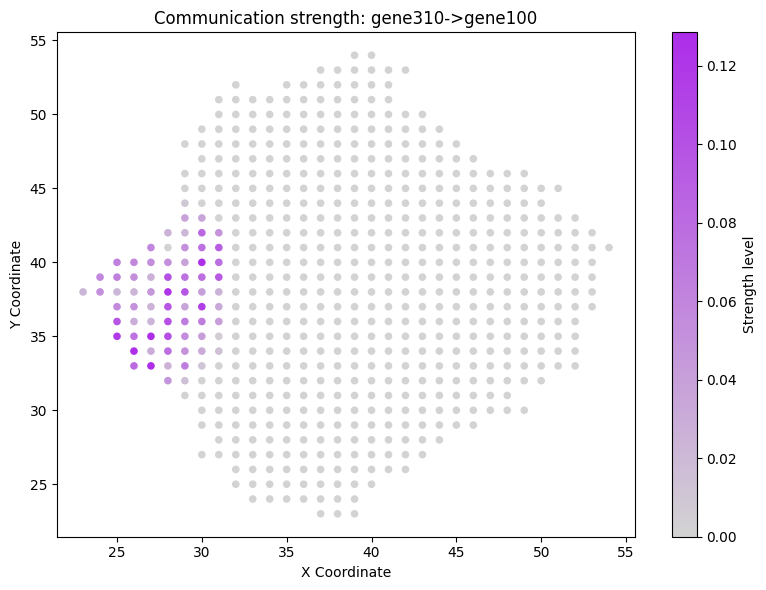

In [77]:
cell_clus.rename(columns={'celltype': 'cell_type'}, inplace=True) # Rename column to 'cell_type' to ensure consistency with downstream analysis functions 
MC.pl.plot_comm_strength(
    comm_item='gene310->gene100',
    comm_score=sample_inter_df,
    cell_loc=cell_loc,
    cell_clus=cell_clus,
    log_transform=False
)

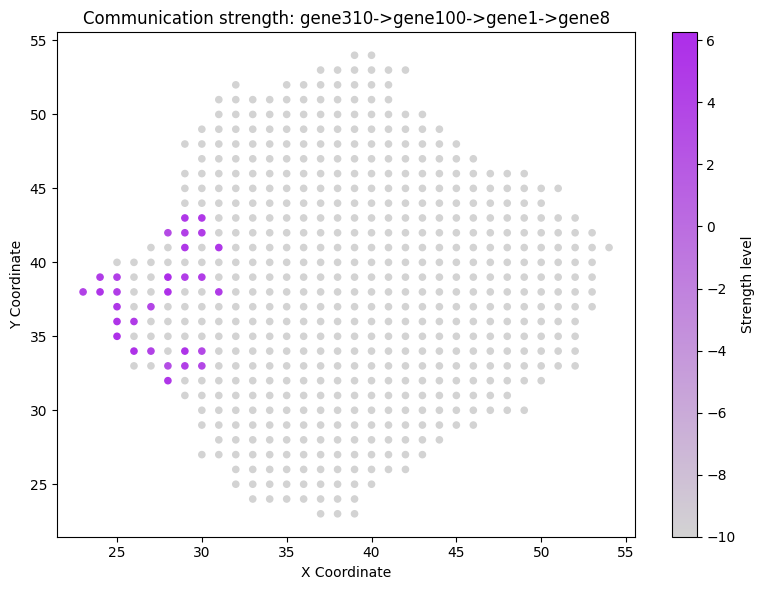

In [78]:
MC.pl.plot_comm_strength(
    comm_item='gene310->gene100->gene1->gene8',
    comm_score=sample_ccc_df,
    cell_loc=cell_loc,
    cell_clus=cell_clus,
    log_transform=True
)

### Plot the CCC-driven information flow for focused pair/path

In [79]:
color_map = {
    'celltype1': '#1f77b4',       
    'celltype2': '#ff7f0e', 
    'celltype3': '#2ca02c', 
    'celltype4': '#d62728',   
    'celltype5': '#9467bd'   
}

coord_df = cell_loc.copy()
coord_df['color'] = cell_clus['cell_type'].map(color_map)

[INFO] Loading Nei_adj from: /home/nas3/biod/zhencaiwei/MultiChat-main/Datasets/Simulation/Simu040/CCC/Nei_adj.csv


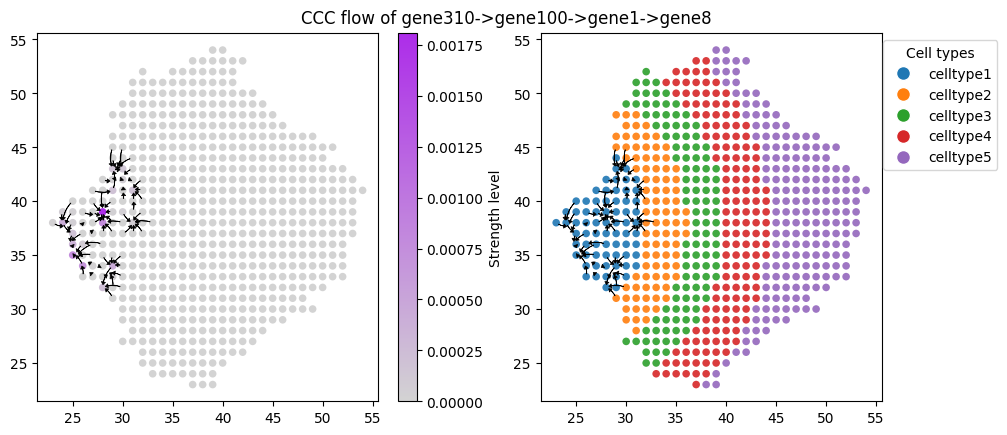

In [80]:
MC.pl.run_plot_communication_double_panel(
    path_name='gene310->gene100->gene1->gene8',
    base_path=base_path,
    cell_clus=cell_clus,
    cell_loc=cell_loc,
    meta_df=coord_df,
    color_map=color_map,
    Sig_path_path=base_path + 'CCC/Significant_paths.csv',
    ccc=sample_ccc_df,
    figpath=None
)